## IPL match prediction 

In [1]:
import pandas as pd

In [4]:
matches =  pd.read_csv("ipl.csv")
deliveries = pd.read_csv("deliveries.csv")

deliveries.head()
matches.head()


,team1,team2,match_date,toss_winner,toss_decision,winner,player_of_match,venue,city,team1_players,team2_players,season,match_number,match_type,result,result_margin,target_runs,target_overs,super_over
0,Royal Challengers Bangalore,Kolkata Knight Riders,2008-04-18,Royal Challengers Bangalore,field,Kolkata Knight Riders,BB McCullum,M Chinnaswamy Stadium,Bangalore,"R Dravid, W Jaffer, V Kohli, JH Kallis, CL Whi...","SC Ganguly, BB McCullum, RT Ponting, DJ Hussey...",1,1,League,runs,140.0,223.0,20.0,N
1,Kings XI Punjab,Chennai Super Kings,2008-04-19,Chennai Super Kings,bat,Chennai Super Kings,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Chandigarh,"K Goel, JR Hopes, KC Sangakkara, Yuvraj Singh,...","PA Patel, ML Hayden, MEK Hussey, MS Dhoni, SK ...",1,2,League,runs,33.0,241.0,20.0,N
2,Delhi Daredevils,Rajasthan Royals,2008-04-19,Rajasthan Royals,bat,Delhi Daredevils,MF Maharoof,Feroz Shah Kotla,Delhi,"G Gambhir, V Sehwag, S Dhawan, MK Tiwary, KD K...","T Kohli, YK Pathan, SR Watson, M Kaif, DS Lehm...",1,3,League,wickets,9.0,130.0,20.0,N
3,Mumbai Indians,Royal Challengers Bangalore,2008-04-20,Mumbai Indians,bat,Royal Challengers Bangalore,MV Boucher,Wankhede Stadium,Mumbai,"L Ronchi, ST Jayasuriya, DJ Thornely, RV Uthap...","S Chanderpaul, R Dravid, LRPL Taylor, JH Kalli...",1,4,League,wickets,5.0,166.0,20.0,N
4,Kolkata Knight Riders,Deccan Chargers,2008-04-20,Deccan Chargers,bat,Kolkata Knight Riders,DJ Hussey,Eden Gardens,Kolkata,"WP Saha, BB McCullum, RT Ponting, SC Ganguly, ...","AC Gilchrist, Y Venugopal Rao, VVS Laxman, A S...",1,5,League,wickets,5.0,111.0,20.0,N


In [5]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [6]:
matches['match_id'] = range(1, len(matches) + 1)

In [7]:
print(matches[['match_id', 'team1', 'team2']].head())
print(deliveries[['match_id', 'batter']].head())


   match_id                        team1                        team2
0         1  Royal Challengers Bangalore        Kolkata Knight Riders
1         2              Kings XI Punjab          Chennai Super Kings
2         3             Delhi Daredevils             Rajasthan Royals
3         4               Mumbai Indians  Royal Challengers Bangalore
4         5        Kolkata Knight Riders              Deccan Chargers
   match_id       batter
0    335982   SC Ganguly
1    335982  BB McCullum
2    335982  BB McCullum
3    335982  BB McCullum
4    335982  BB McCullum


In [8]:
print(deliveries['match_id'].unique()[:10])
print(len(deliveries['match_id'].unique()))

[335982 335983 335984 335985 335986 335987 335988 335989 335990 335991]
1095


In [10]:
# Count balls faced
balls = deliveries.groupby('batter')['ball'].count()

# Total runs
runs = deliveries.groupby('batter')['batsman_runs'].sum()

# Filter players with minimum 100 balls
valid_players = balls[balls > 100].index

# Calculate strike rate
strike_rate = (runs[valid_players] / balls[valid_players]) * 100

print(strike_rate.sort_values(ascending=False).head(10))


batter
J Fraser-McGurk    220.000000
WG Jacks           172.932331
PD Salt            169.610390
T Stubbs           169.456067
TM Head            168.558952
AD Russell         164.224422
BCJ Cutting        163.013699
H Klaasen          161.990212
Ramandeep Singh    160.377358
Ashutosh Sharma    160.169492
dtype: float64


In [13]:
player_stats = pd.DataFrame({
    'matches': deliveries.groupby('batter')['match_id'].nunique(),
    'runs': deliveries.groupby('batter')['batsman_runs'].sum(),
    'balls': deliveries.groupby('batter')['ball'].count()
})

player_stats['strike_rate'] = (player_stats['runs'] / player_stats['balls']) * 100

# filter serious players
player_stats = player_stats[player_stats['balls'] > 100]

player_stats = player_stats.sort_values(by='runs', ascending=False)

print(player_stats.head())


           matches  runs  balls  strike_rate
batter                                      
V Kohli        244  8014   6236   128.511867
S Dhawan       221  6769   5483   123.454313
RG Sharma      251  6630   5183   127.918194
DA Warner      184  6567   4849   135.429986
SK Raina       200  5536   4177   132.535312


In [14]:
get_player_profile("V Kohli")


Player: V Kohli
Matches: 244.0
Runs: 8014.0
Balls: 6236.0
Strike Rate: 128.51


In [15]:
def get_player_profile(player_name):
    # make search flexible
    player_list = player_stats.index.tolist()
    
    matched_players = [p for p in player_list if player_name.lower() in p.lower()]
    
    if not matched_players:
        print("Player not found")
        return
    
    player = matched_players[0]
    stats = player_stats.loc[player]
    
    print(f"\nPlayer: {player}")
    print(f"Matches: {stats['matches']}")
    print(f"Runs: {stats['runs']}")
    print(f"Balls: {stats['balls']}")
    print(f"Strike Rate: {stats['strike_rate']:.2f}")

In [16]:
get_player_profile("kohli")


Player: V Kohli
Matches: 244.0
Runs: 8014.0
Balls: 6236.0
Strike Rate: 128.51


In [22]:
%matplotlib inline

In [24]:
import matplotlib.pyplot as plt

def player_form(player_name):
    player_data = deliveries[deliveries['batter'].str.contains(player_name, case=False, na=False)]
    
    if player_data.empty:
        print("No data found for this player")
        return
    
    runs_per_match = player_data.groupby('match_id')['batsman_runs'].sum()
    
    last_matches = runs_per_match.tail(10)
    
    print(last_matches)  # debug
    
    plt.figure(figsize=(8,5))   # important
    plt.plot(last_matches.index, last_matches.values, marker='o')
    plt.title(f"{player_name} - Last 10 Matches Form")
    plt.xlabel("Match ID")
    plt.ylabel("Runs")
    plt.grid()
    plt.show()

match_id
1426263     3
1426268    42
1426274    18
1426279    51
1426283    70
1426290    42
1426296    92
1426300    27
1426306    47
1426310    33
Name: batsman_runs, dtype: int64


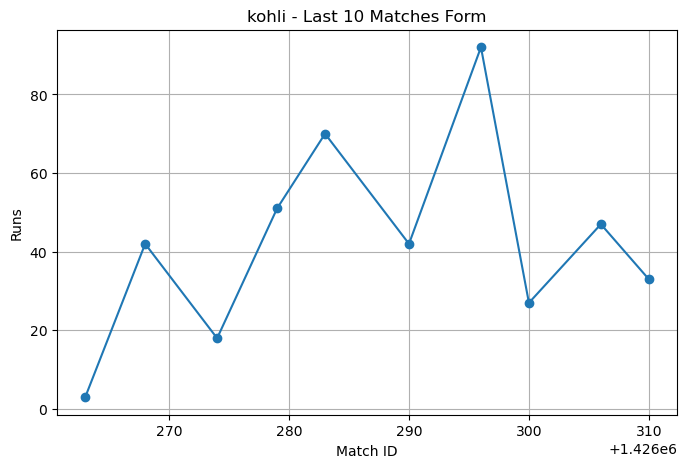

In [25]:
player_form("kohli")

In [21]:
player_data = deliveries[deliveries['batter'].str.contains("kohli", case=False)]

print(player_data.shape)

(6256, 17)


In [26]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

# Load data
deliveries = pd.read_csv("deliveries.csv")

# Create player stats
player_stats = pd.DataFrame({
    'matches': deliveries.groupby('batter')['match_id'].nunique(),
    'runs': deliveries.groupby('batter')['batsman_runs'].sum(),
    'balls': deliveries.groupby('batter')['ball'].count()
})

player_stats['strike_rate'] = (player_stats['runs'] / player_stats['balls']) * 100
player_stats = player_stats[player_stats['balls'] > 100]

# UI Title
st.title("🏏 IPL Player Analytics")

# Input
player_name = st.text_input("Enter Player Name")

if player_name:
    player_list = player_stats.index.tolist()
    matched_players = [p for p in player_list if player_name.lower() in p.lower()]
    
    if matched_players:
        player = matched_players[0]
        stats = player_stats.loc[player]
        
        st.subheader(f"Player: {player}")
        st.write(f"Matches: {int(stats['matches'])}")
        st.write(f"Runs: {int(stats['runs'])}")
        st.write(f"Strike Rate: {stats['strike_rate']:.2f}")
        
        # Form graph
        player_data = deliveries[deliveries['batter'] == player]
        runs_per_match = player_data.groupby('match_id')['batsman_runs'].sum()
        last_matches = runs_per_match.tail(10)
        
        fig, ax = plt.subplots()
        ax.plot(last_matches.index, last_matches.values, marker='o')
        ax.set_title("Last 10 Matches Performance")
        ax.set_xlabel("Match ID")
        ax.set_ylabel("Runs")
        
        st.pyplot(fig)
        
    else:
        st.write("Player not found")

2026-04-01 20:42:49.795 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 20:42:50.361 
  command:

    streamlit run e:\Users\HP\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-04-01 20:42:50.362 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 20:42:50.363 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 20:42:50.365 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 20:42:50.367 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 20:42:50.368 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-01 20:42:50.374 Thread 'MainThread': missi